## Sales Data Analysis Project
This project analyzes sales data to understand revenue trends, top products, and performance by region and sales reps.

## 1. Create and Inspect Dataset
In this project, I generated a synthetic sales dataset to simulate real world business data. I then inspected the structure to understand the available columns and data types.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

sales_rep = [
    "Michael", "Sarah", "David", "Emily", "James",
    "Olivia", "Christopher", "Ava", "Daniel", "Sophia",
    "Matthew", "Isabella", "Anthony", "Mia", "Joshua"
]
region = [
    'Midwest',
    'Northeast',
    'South',
    'West'
]
product = [
    "Laptop",
    "Wireless Mouse",
    "Keyboard",
    "Monitor",
    "USB-C Hub",
    "Headphones",
    "Webcam",
    "External Hard Drive",
    "Printer",
    "Desk Chair",
    "Tablet",
    "Smartphone",
    "Microphone",
    "Gaming Mouse",
    "Docking Station"
]
quantity = [
    1, 2, 3, 4, 5,
    1, 2, 3, 1, 2,
    4, 5, 2, 3, 1
]
unit_price = [
    899.99,
    24.99,
    49.99,
    249.99,
    39.99,
    89.99,
    59.99,
    119.99,
    179.99,
    299.99,
    399.99,
    799.99,
    129.99,
    54.99,
    149.99
]
date = [
    "2026-01-03",
    "2026-01-07",
    "2026-01-12",
    "2026-01-15",
    "2026-01-21",
    "2026-02-02",
    "2026-02-08",
    "2026-02-14",
    "2026-02-20",
    "2026-03-01",
    "2026-03-07",
    "2026-03-15",
    "2026-03-22",
    "2026-03-28",
    "2026-04-05"
]

In [13]:
random.choice(sales_rep)
random.choice(region)
random.choice(product)
random.choice(quantity)
random.choice(unit_price)
random.choice(date)

'2026-03-15'

In [15]:
entry = {
    'Date': random.choice(date),
    'Order Id': random.randint(100, 999),
    'Sales Rep': random.choice(sales_rep),
    'Region': random.choice(region),
    'Product': random.choice(product),
    'Quantity': random.choice(quantity),
    'Price': random.choice(unit_price)
}

entry

{'Date': '2026-03-15',
 'Order Id': 367,
 'Sales Rep': 'Matthew',
 'Region': 'Northeast',
 'Product': 'Desk Chair',
 'Quantity': 2,
 'Price': 24.99}

In [16]:
entries = []

for i in range(200):
  entry = {
      'Date': random.choice(date),
    'Order Id': random.randint(100, 999),
    'Sales Rep': random.choice(sales_rep),
    'Region': random.choice(region),
    'Product': random.choice(product),
    'Quantity': random.choice(quantity),
    'Price': random.choice(unit_price)
  }
  entries.append(entry)

## 2. Initial Data Inspection and Feature Creation

After creating the dataset, I inspected its structure by reviewing column names, data types, and sample records to better understand the data.

I also created a new column called **Revenue** by multiplying **Price** and **Quantity**. This column represents the total sales value for each transaction and is used for further analysis such as revenue trends and performance comparisons.

In [18]:
df = pd.DataFrame(entries)
df.head()

,Date,Order Id,Sales Rep,Region,Product,Quantity,Price
0,2026-01-03,756,Matthew,Midwest,USB-C Hub,1,49.99
1,2026-04-05,433,Mia,South,Microphone,2,54.99
2,2026-03-22,984,James,Northeast,Webcam,1,129.99
3,2026-02-02,647,David,South,Webcam,5,299.99
4,2026-03-07,702,Sophia,Northeast,Docking Station,1,89.99


In [19]:
df['Revenue'] = df['Price'] * df['Quantity']
df.head()

,Date,Order Id,Sales Rep,Region,Product,Quantity,Price,Revenue
0,2026-01-03,756,Matthew,Midwest,USB-C Hub,1,49.99,49.99
1,2026-04-05,433,Mia,South,Microphone,2,54.99,109.98
2,2026-03-22,984,James,Northeast,Webcam,1,129.99,129.99
3,2026-02-02,647,David,South,Webcam,5,299.99,1499.95
4,2026-03-07,702,Sophia,Northeast,Docking Station,1,89.99,89.99


## 3. Data Investigation and Business Insights

In this section, I explored the dataset to answer business questions related to overall performance and sales trends.

I calculated the **total company revenue** to understand overall performance. I then used grouping and aggregation techniques to identify the **top sales rep**, **top performing region**, and the **best-selling product**.

To complete this analysis, I used functions such as `sum()` to calculate totals, `groupby()` to organize data by categories, and `sort_values()` to rank results and identify the highest performers.

This step helps highlight which areas of the business are performing well and where the most revenue is being generated.

In [24]:
df['Revenue'].sum()

np.float64(135634.72)

In [55]:
df.groupby('Sales Rep')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Sales Rep,
Isabella,18924.49
Emily,16919.58
Michael,14389.60
Sophia,11314.64
Daniel,10849.55
Christopher,9239.59
Joshua,9039.59
Olivia,8004.71
David,7149.66


In [54]:
df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Region,
Midwest,45653.58
West,37143.46
Northeast,27523.92
South,25313.76


In [53]:
df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Product,
Docking Station,19594.57
USB-C Hub,12484.62
Desk Chair,10874.57
Laptop,10669.65
Smartphone,10609.57
Wireless Mouse,10059.59
External Hard Drive,9874.65
Keyboard,9639.56
Gaming Mouse,8654.70


## 4. Monthly Revenue Analysis

In this section, I extended the dataset to include dates spanning multiple months in order to analyze revenue trends over time.

I converted the **Date** column into a proper datetime format using `pd.to_datetime()` so that it could be used for time based analysis. From there, I extracted the month information and used it to group the data by month.

Finally, I calculated total revenue for each month to determine which month generated the highest revenue. This analysis helps identify seasonal patterns and performance trends over time.

In [60]:
df['Date'] = pd.to_datetime(df['Date'])

In [57]:
pd.to_datetime(df['Date'])

,Date
0,2026-01-03
1,2026-04-05
2,2026-03-22
3,2026-02-02
4,2026-03-07
...,...
195,2026-02-02
196,2026-03-01
197,2026-03-15
198,2026-02-08


In [63]:
df['Month'] = df['Date'].dt.month

In [66]:
df.groupby('Month')['Revenue'].sum().sort_values(ascending=False)

,Revenue
Month,
1,51818.28
3,46662.89
2,35358.79
4,1794.76


## 5. Data Visualization

In this section, I created visualizations to better understand sales performance across different dimensions of the dataset.

I built three key charts:

- **Revenue by Region** to compare total sales performance across different geographic areas.
- **Revenue by Sales Rep** to identify top-performing individuals based on total revenue generated.
- **Revenue Over Time** to analyze trends and understand how revenue changes across different time periods.

These visualizations help transform raw data into clear insights and support a more intuitive understanding of business performance patterns.

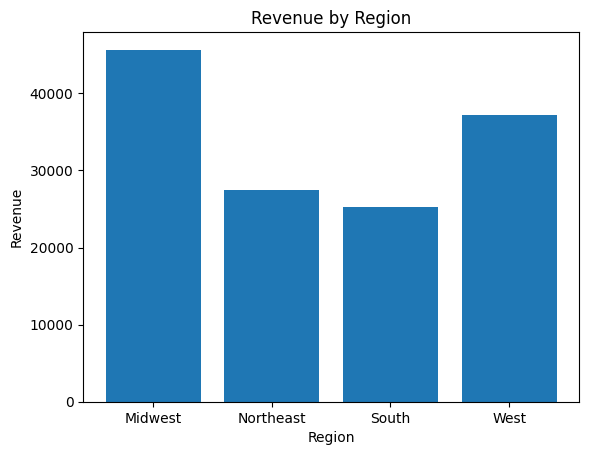

In [68]:
region_revenue = df.groupby('Region')['Revenue'].sum()
plt.bar(region_revenue.index, region_revenue.values)

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue')

plt.show()

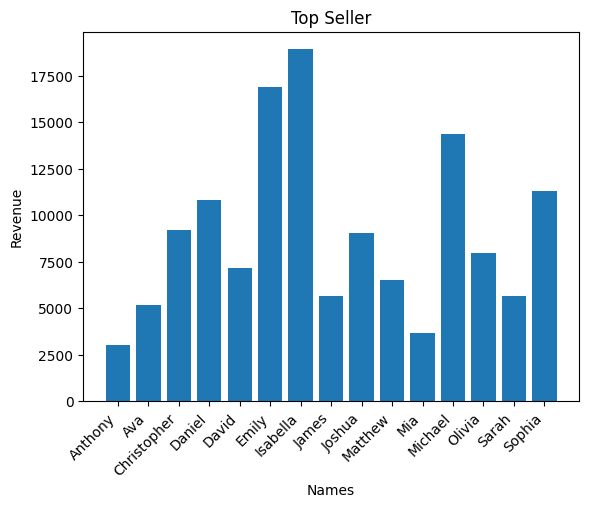

In [71]:
top_sales_rep = df.groupby('Sales Rep')['Revenue'].sum()
plt.bar(top_sales_rep.index, top_sales_rep.values)

plt.title('Top Seller')
plt.xlabel("Names")
plt.xticks(rotation=45, ha='right')
plt.ylabel('Revenue')

plt.show()

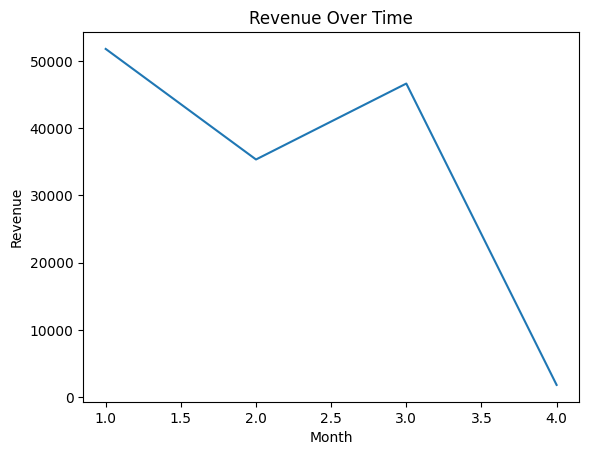

In [72]:
over_time_sales = df.groupby('Month')['Revenue'].sum()
plt.plot(over_time_sales.index, over_time_sales.values)

plt.title('Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.show()